In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
record_df = pd.read_csv('../data/raw/100.csv')
record_df.columns = [col.strip("'") for col in record_df.columns]
# Now you can use clean names
signal_mlii = record_df['MLII'].values
signal_v5 = record_df['V5'].values
sample_idx = record_df['sample #'].values
print(f"Loaded {len(signal_mlii)} samples")
print(f"MLII range: {signal_mlii.min()} to {signal_mlii.max()}")


Loaded 650000 samples
MLII range: 481 to 1311


In [4]:
from scipy.signal import butter, filtfilt

In [5]:


def butter_bandpass_filter(data, lowcut=0.5, highcut=40.0, fs=360, order=4):
    nyq = 0.5 * fs  # Nyquist Frequency
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data) # filtfilt applies it twice to prevent phase shift
    return y

# Apply it to your MLII signal
fs = 360 # MIT-BIH sampling rate is 360Hz
filtered_signal = butter_bandpass_filter(signal_mlii, lowcut=0.5, highcut=40.0, fs=fs)

# Check the difference!


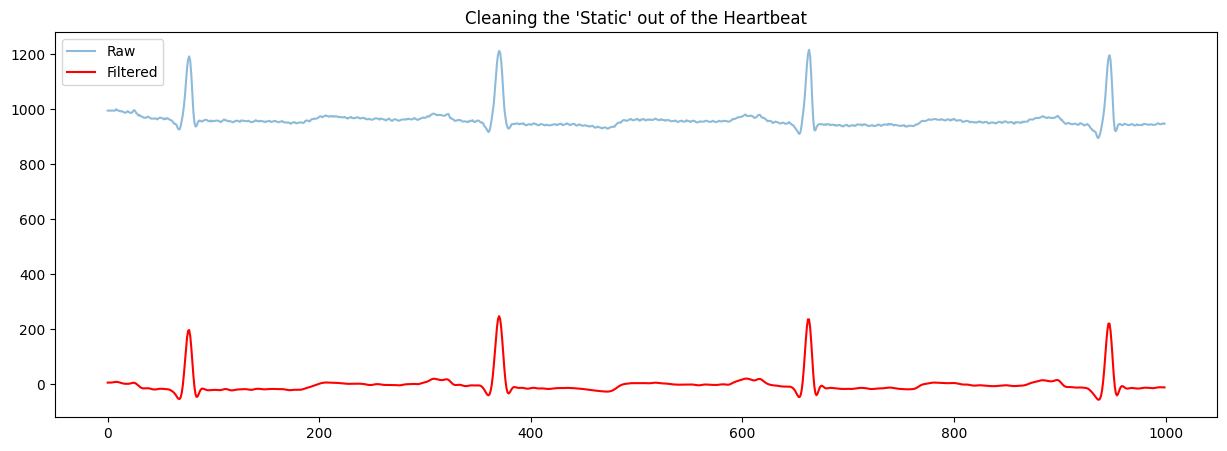

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.plot(signal_mlii[:1000], label='Raw', alpha=0.5)
plt.plot(filtered_signal[:1000], label='Filtered', color='red')
plt.legend()
plt.title("Cleaning the 'Static' out of the Heartbeat")
plt.show()

In [7]:
from scipy.signal import find_peaks

def segment_heartbeats(signal, window_size=180):
    # Find peaks: distance=200 ensures we don't pick two peaks in one beat
    # height=0.5 (or similar) ensures we don't pick up small noise as a peak
    peaks, _ = find_peaks(signal, distance=200, height=0.2 * np.max(signal))
    
    beats = []
    half_window = window_size // 2
    
    for p in peaks:
        # Ensure we don't go out of bounds at the start or end of the signal
        if p > half_window and p < len(signal) - half_window:
            segment = signal[p - half_window : p + half_window]
            beats.append(segment)
            
    return np.array(beats), peaks

# Segment your filtered MLII signal
beats, peak_indices = segment_heartbeats(filtered_signal)

print(f"Total heartbeats extracted: {len(beats)}")
print(f"Shape of each beat: {beats[0].shape}")

Total heartbeats extracted: 2263
Shape of each beat: (180,)


In [8]:
# Load annotations from text file
import pandas as pd

# Create a simple class to mimic wfdb annotation structure
class Annotation:
    def __init__(self, samples, symbols):
        self.sample = samples
        self.symbol = symbols

# Parse the annotation file
ann_data = []
with open('../data/raw/100annotations.txt', 'r') as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 3:
            try:
                sample_num = int(parts[1])  # Sample number is 2nd column
                symbol = parts[2]           # Type/symbol is 3rd column
                ann_data.append((sample_num, symbol))
            except ValueError:
                continue

# Create annotation object
samples = [x[0] for x in ann_data]
symbols = [x[1] for x in ann_data]
annotation = Annotation(samples, symbols)

print(f"Loaded {len(annotation.sample)} annotations")
print(f"Beat types found: {set(annotation.symbol)}")

Loaded 2274 annotations
Beat types found: {'A', 'N', '+', 'V'}


In [9]:
def get_labels(peak_indices, annotation, beats):
    """
    Get labels for segmented beats.
    
    Args:
        peak_indices: Array of detected R-peak indices
        annotation: Annotation object with .sample and .symbol
        beats: Array of segmented heartbeats
    """
    label_map = {
        'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,  # Group as Normal (0)
        'A': 1, 'a': 1, 'J': 1, 'S': 1,          # Group as Supraventricular (1)
        'V': 2, 'E': 2,                          # Group as Ventricular (2)
        'F': 3,                                  # Group as Fusion (3)
        '/': 4, 'f': 4, 'Q': 4                   # Group as Paced/Unknown (4)
    }
    
    final_beats = []
    final_labels = []
    
    ann_indices = np.array(annotation.sample)
    ann_symbols = annotation.symbol
    
    # FIXED: Only iterate up to the number of beats we have
    num_beats = len(beats)
    
    for i in range(num_beats):
        if i >= len(peak_indices):
            break
            
        peak = peak_indices[i]
        
        # Find the closest annotation to our detected peak
        closest_ann_idx = np.argmin(np.abs(ann_indices - peak))
        symbol = ann_symbols[closest_ann_idx]
        
        if symbol in label_map:
            final_beats.append(beats[i])
            final_labels.append(label_map[symbol])
            
    return np.array(final_beats), np.array(final_labels)

# Call with beats as parameter
X, y = get_labels(peak_indices, annotation, beats)
print(f"Dataset Ready! Features: {X.shape}, Labels: {y.shape}")

Dataset Ready! Features: (2263, 180), Labels: (2263,)


In [10]:
from sklearn.utils import class_weight

# Calculate weights based on your 'y' labels
weights = class_weight.compute_class_weight('balanced', 
                                            classes=np.unique(y), 
                                            y=y)
class_weights = dict(enumerate(weights))
print(f"Calculated Class Weights: {class_weights}")

Calculated Class Weights: {0: np.float64(0.3378116136736826), 1: np.float64(26.011494252873565), 2: np.float64(754.3333333333334)}


In [11]:
# Restart kernel fix - run this FIRST
import importlib
import sys

# Remove cached module
if 'src.preprocess' in sys.modules:
    del sys.modules['src.preprocess']
if 'src' in sys.modules:
    del sys.modules['src']

# Now import fresh
sys.path.insert(0, '..')
from src.preprocess import ECGPreprocessor

print("✅ Import successful!")

c:\Users\mayank goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 180, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 90, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 90, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 45, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,061 (238.52 KB)

 Trainable params: 60,613 (236.77 KB)

 Non-trainable params: 448 (1.75 KB)

✅ Import successful!


In [12]:
# Clear cached import
import sys
if 'src.preprocess' in sys.modules:
    del sys.modules['src.preprocess']
if 'src' in sys.modules:
    del sys.modules['src']

from src.preprocess import ECGPreprocessor

# 1. Initialize the preprocessor
preprocessor = ECGPreprocessor(fs=360, window_size=180)

# 2. Process the signal
beats, peak_indices = preprocessor.segment_beats(filtered_signal)

# 3. Match with labels — now pass 'beats' as first argument ✅
X, y = preprocessor.map_labels(beats, peak_indices, annotation)

# 💡 Check class distribution
import numpy as np
classes, counts = np.unique(y, return_counts=True)
print(f"✅ Class distribution: {dict(zip(classes, counts))}")

✅ Class distribution: {np.int64(0): np.int64(2233), np.int64(1): np.int64(29)}


In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import os

In [15]:
os.makedirs('../models', exist_ok=True)
# Reshape for CNN: (samples, timesteps, channels)
X_reshaped = X.reshape(-1, 180, 1)
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42, stratify=y
)
# ⚖️ Compute class weights (crucial for imbalanced medical data!)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print(f"📊 Class Weights: {class_weights}")
# Build model
from src.model import build_1d_cnn
model = build_1d_cnn(input_shape=(180, 1), num_classes=len(np.unique(y)))
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('../models/best_ecg_model.h5', monitor='val_accuracy', save_best_only=True)
# 🚀 THE BIG MOMENT: Training
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)
print("✅ Training Complete!")

📊 Class Weights: {0: np.float64(0.5064389697648376), 1: np.float64(39.32608695652174)}


c:\Users\mayank goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
55/57 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5672 - loss: 0.7850

57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5301 - loss: 0.6307 - val_accuracy: 0.0132 - val_loss: 1.1786
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7032 - loss: 0.5102 - val_accuracy: 0.0132 - val_loss: 2.9371
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7673 - loss: 0.4063 - val_accuracy: 0.0132 - val_loss: 7.3758
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8060 - loss: 0.3250 - val_accuracy: 0.0132 - val_loss: 9.4162
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8767 - loss: 0.2977 - val_accuracy: 0.0132 - val_loss: 10.6306
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8839 - loss: 0.2697 - val_accuracy: 0.0132 - val_loss: 11.1250
✅ Training Complete!


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
--- Classification Report ---
                  precision    recall  f1-score   support

          Normal       0.00      0.00      0.00       447
Supraventricular       0.01      1.00      0.03         6

        accuracy                           0.01       453
       macro avg       0.01      0.50      0.01       453
    weighted avg       0.00      0.01      0.00       453



c:\Users\mayank goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mayank goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mayank goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

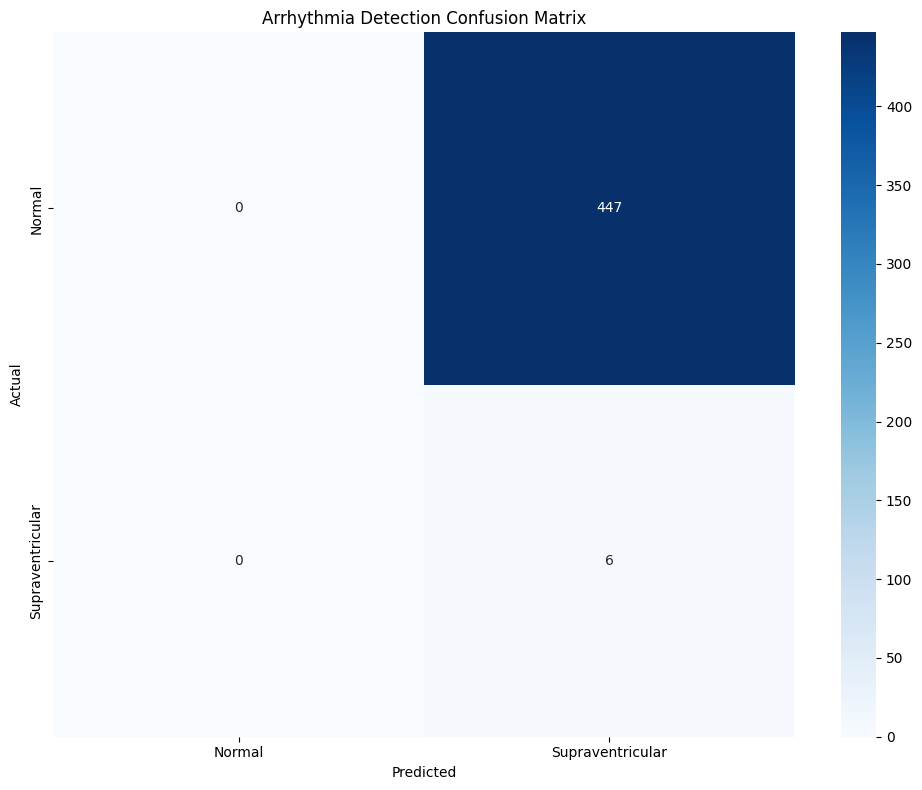


✅ Test Accuracy: 1.32%


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get Predictions on TEST set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Generate Report
class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Paced']
# Only use labels that exist in the data
unique_labels = np.unique(np.concatenate([y_test, y_pred]))
used_names = [class_names[i] for i in unique_labels]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, labels=unique_labels, target_names=used_names))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=used_names,
            yticklabels=used_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Arrhythmia Detection Confusion Matrix')
plt.tight_layout()
plt.show()

# 4. Overall accuracy
accuracy = np.sum(y_pred == y_test) / len(y_test)
print(f"\n✅ Test Accuracy: {accuracy:.2%}")

In [18]:
import os
import numpy as np
import pandas as pd
from src.preprocess import ECGPreprocessor

In [19]:
reprocessor = ECGPreprocessor(fs=360, window_size=180)
# Annotation loader
class Annotation:
    def __init__(self, samples, symbols):
        self.sample = np.array(samples)
        self.symbol = symbols
def load_annotation(path):
    ann_data = []
    with open(path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 3:
                try:
                    ann_data.append((int(parts[1]), parts[2]))
                except ValueError:
                    continue
    return Annotation([x[0] for x in ann_data], [x[1] for x in ann_data])
# 🔥 Process ALL records
data_dir = '../data/raw'
all_X, all_y = [], []
csv_files = sorted([f.replace('.csv', '') for f in os.listdir(data_dir) if f.endswith('.csv')])
print(f"Found {len(csv_files)} patient records")
for record_id in csv_files:
    try:
        # Load signal
        df = pd.read_csv(f'{data_dir}/{record_id}.csv')
        df.columns = [col.strip("'") for col in df.columns]
        signal = df['MLII'].values
        
        # Load annotation
        annotation = load_annotation(f'{data_dir}/{record_id}annotations.txt')
        
        # Preprocess
        filtered = preprocessor.apply_filter(signal)
        beats, peaks = preprocessor.segment_beats(filtered)
        X, y = preprocessor.map_labels(beats, peaks, annotation)
        
        all_X.append(X)
        all_y.append(y)
        print(f"  ✅ Record {record_id}: {len(X)} beats")
        
    except Exception as e:
        print(f"  ❌ Record {record_id}: {e}")
# Combine all records
X = np.concatenate(all_X)
y = np.concatenate(all_y)
print(f"\n🎯 TOTAL Dataset: {X.shape[0]} beats")
classes, counts = np.unique(y, return_counts=True)
class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Paced']
for c, n in zip(classes, counts):
    print(f"   {class_names[c]}: {n} ({n/len(y)*100:.1f}%)")

Found 48 patient records
  ✅ Record 100: 2262 beats
  ✅ Record 101: 1860 beats
  ❌ Record 102: 'MLII'
  ✅ Record 103: 2084 beats
  ❌ Record 104: 'MLII'
  ✅ Record 105: 2462 beats
  ✅ Record 106: 1617 beats
  ✅ Record 107: 2079 beats
  ✅ Record 108: 1178 beats
  ✅ Record 109: 2504 beats
  ✅ Record 111: 2033 beats
  ✅ Record 112: 2538 beats
  ✅ Record 113: 1788 beats
  ✅ Record 114: 1831 beats
  ✅ Record 115: 1952 beats
  ✅ Record 116: 2284 beats
  ✅ Record 117: 1521 beats
  ✅ Record 118: 2242 beats
  ✅ Record 119: 1622 beats
  ✅ Record 121: 1859 beats
  ✅ Record 122: 2476 beats
  ✅ Record 123: 1514 beats
  ✅ Record 124: 1577 beats
  ✅ Record 200: 1816 beats
  ✅ Record 201: 1535 beats
  ✅ Record 202: 1771 beats
  ✅ Record 203: 1841 beats
  ✅ Record 205: 2580 beats
  ✅ Record 207: 208 beats
  ✅ Record 208: 2135 beats
  ✅ Record 209: 2642 beats
  ✅ Record 210: 2364 beats
  ✅ Record 212: 2744 beats
  ✅ Record 213: 2062 beats
  ✅ Record 214: 2024 beats
  ✅ Record 215: 1928 beats
  ✅ Record 2

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [21]:
X_reshaped = X.reshape(-1, 180, 1)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

In [24]:
lass_weights = dict(enumerate(class_weights))
print(f"✅ Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"⚖️ Class Weights: {class_weights}")

✅ Train: 73420 samples | Test: 18355 samples
⚖️ Class Weights: [ 0.22301535  8.73527662  6.64133876 24.47333333  4.75980551]


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

In [26]:
os.makedirs('../models', exist_ok=True)


In [27]:
num_classes = len(np.unique(y))

In [28]:
model = models.Sequential([
    # Block 1
    layers.Conv1D(32, kernel_size=5, padding='same', activation='relu', input_shape=(180, 1)),
    layers.BatchNormalization(),
    layers.MaxPool1D(pool_size=2),
    
    # Block 2
    layers.Conv1D(64, kernel_size=5, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool1D(pool_size=2),
    layers.Dropout(0.3),
    
    # Block 3
    layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    
    # Dense
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

c:\Users\mayank goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 180, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 180, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 90, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 90, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 90, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 45, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 45, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,677 (174.52 KB)

 Trainable params: 44,229 (172.77 KB)

 Non-trainable params: 448 (1.75 KB)

In [32]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
checkpoint = ModelCheckpoint('../models/best_ecg_model.h5', monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# 🚀 Train!
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight={int(i): float(w) for i, w in enumerate(class_weights)},
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("✅ Training Complete!")

Epoch 1/50
1145/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5288 - loss: 0.7844

1148/1148 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.6467 - loss: 0.6205 - val_accuracy: 0.7912 - val_loss: 0.5915 - learning_rate: 0.0010
Epoch 2/50
1146/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7775 - loss: 0.4474

1148/1148 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.7962 - loss: 0.4263 - val_accuracy: 0.8944 - val_loss: 0.3813 - learning_rate: 0.0010
Epoch 3/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.8354 - loss: 0.3620 - val_accuracy: 0.8892 - val_loss: 0.3909 - learning_rate: 0.0010
Epoch 4/50
1147/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8493 - loss: 0.3208

1148/1148 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.8552 - loss: 0.3174 - val_accuracy: 0.9267 - val_loss: 0.2867 - learning_rate: 0.0010
Epoch 5/50
1144/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8691 - loss: 0.2925

1148/1148 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8643 - loss: 0.3031 - val_accuracy: 0.9506 - val_loss: 0.2131 - learning_rate: 0.0010
Epoch 6/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8734 - loss: 0.2830 - val_accuracy: 0.9304 - val_loss: 0.2696 - learning_rate: 0.0010
Epoch 7/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8837 - loss: 0.2660 - val_accuracy: 0.9075 - val_loss: 0.3101 - learning_rate: 0.0010
Epoch 8/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.8885 - loss: 0.2489 - val_accuracy: 0.9414 - val_loss: 0.2199 - learning_rate: 0.0010
Epoch 9/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.9003 - loss: 0.2157 - val_accuracy: 0.9340 - val_loss: 0.2290 - learning_rate: 5.0000e-04
Epoch 10/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.9055 - loss: 0.2058 - val_accuracy: 0.9328 - val_loss: 0.2372 - learning_rate: 5.0000e-04
Epoch 11/50
1145/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy

1148/1148 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.9033 - loss: 0.2015 - val_accuracy: 0.9572 - val_loss: 0.1472 - learning_rate: 5.0000e-04
Epoch 12/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9105 - loss: 0.1882 - val_accuracy: 0.9559 - val_loss: 0.1545 - learning_rate: 5.0000e-04
Epoch 13/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.9080 - loss: 0.1950 - val_accuracy: 0.9491 - val_loss: 0.1795 - learning_rate: 5.0000e-04
Epoch 14/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 28s 24ms/step - accuracy: 0.9149 - loss: 0.1823 - val_accuracy: 0.9492 - val_loss: 0.1812 - learning_rate: 5.0000e-04
Epoch 15/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 28s 24ms/step - accuracy: 0.9194 - loss: 0.1683 - val_accuracy: 0.9536 - val_loss: 0.1611 - learning_rate: 2.5000e-04
Epoch 16/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.9193 - loss: 0.1641 - val_accuracy: 0.9551 - val_loss: 0.1527 - learning_rate: 2.5000e-04
Epoch 17/50
1147/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 

1148/1148 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.9241 - loss: 0.1572 - val_accuracy: 0.9575 - val_loss: 0.1423 - learning_rate: 2.5000e-04
Epoch 18/50
1146/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9226 - loss: 0.1590

1148/1148 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.9236 - loss: 0.1534 - val_accuracy: 0.9648 - val_loss: 0.1164 - learning_rate: 2.5000e-04
Epoch 19/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9263 - loss: 0.1541 - val_accuracy: 0.9576 - val_loss: 0.1433 - learning_rate: 2.5000e-04
Epoch 20/50
1146/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9222 - loss: 0.1507

1148/1148 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9241 - loss: 0.1488 - val_accuracy: 0.9651 - val_loss: 0.1212 - learning_rate: 2.5000e-04
Epoch 21/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9272 - loss: 0.1433 - val_accuracy: 0.9303 - val_loss: 0.2082 - learning_rate: 2.5000e-04
Epoch 22/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9320 - loss: 0.1383 - val_accuracy: 0.9541 - val_loss: 0.1499 - learning_rate: 1.2500e-04
Epoch 23/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.9314 - loss: 0.1389 - val_accuracy: 0.9583 - val_loss: 0.1354 - learning_rate: 1.2500e-04
Epoch 24/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.9334 - loss: 0.1305 - val_accuracy: 0.9572 - val_loss: 0.1375 - learning_rate: 1.2500e-04
Epoch 25/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.9330 - loss: 0.1307 - val_accuracy: 0.9626 - val_loss: 0.1193 - learning_rate: 6.2500e-05
✅ Training Complete!


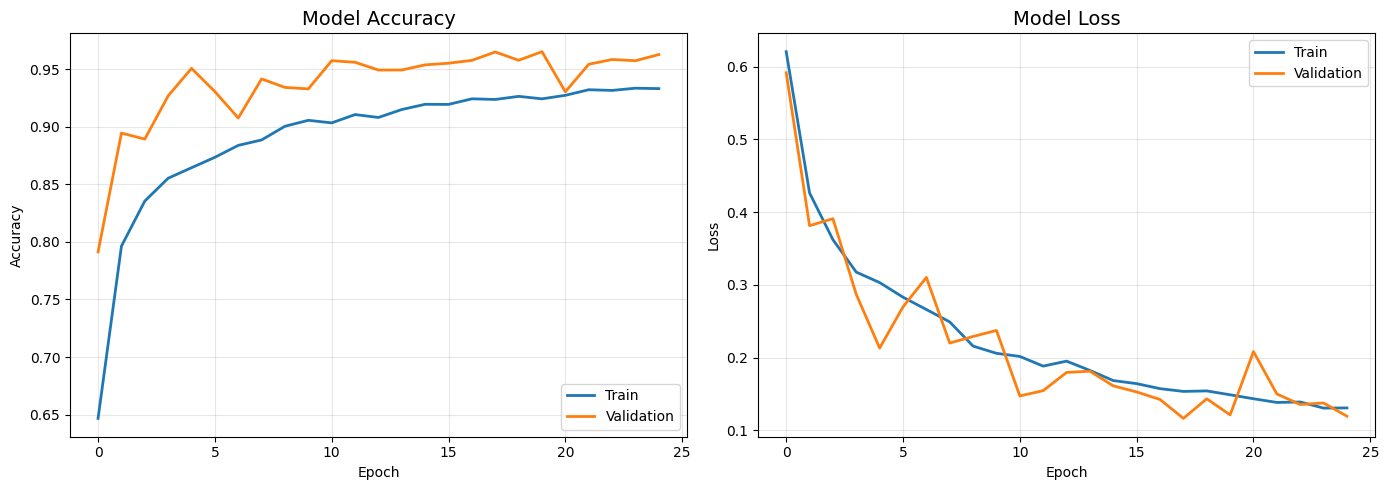

In [33]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/training_history.png', dpi=150)
plt.show()

In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [35]:
y_pred = np.argmax(model.predict(X_test), axis=1)
# Class names
class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Paced']
unique_labels = np.unique(np.concatenate([y_test, y_pred]))
used_names = [class_names[i] for i in unique_labels]

574/574 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


In [36]:
print("=" * 60)
print("         ARRHYTHMIA DETECTION — FINAL RESULTS")
print("=" * 60)
print(classification_report(y_test, y_pred, labels=unique_labels, target_names=used_names))

         ARRHYTHMIA DETECTION — FINAL RESULTS
                  precision    recall  f1-score   support

          Normal       1.00      0.97      0.98     16461
Supraventricular       0.52      0.92      0.66       420
     Ventricular       0.90      0.94      0.92       553
          Fusion       0.46      0.95      0.62       150
           Paced       0.98      1.00      0.99       771

        accuracy                           0.96     18355
       macro avg       0.77      0.95      0.84     18355
    weighted avg       0.98      0.96      0.97     18355



C:\Users\mayank goyal\AppData\Local\Temp\ipykernel_28012\3623966114.py:8: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mayank goyal\AppData\Local\Temp\ipykernel_28012\3623966114.py:9: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  plt.savefig('../models/confusion_matrix.png', dpi=150)
C:\Users\mayank goyal\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


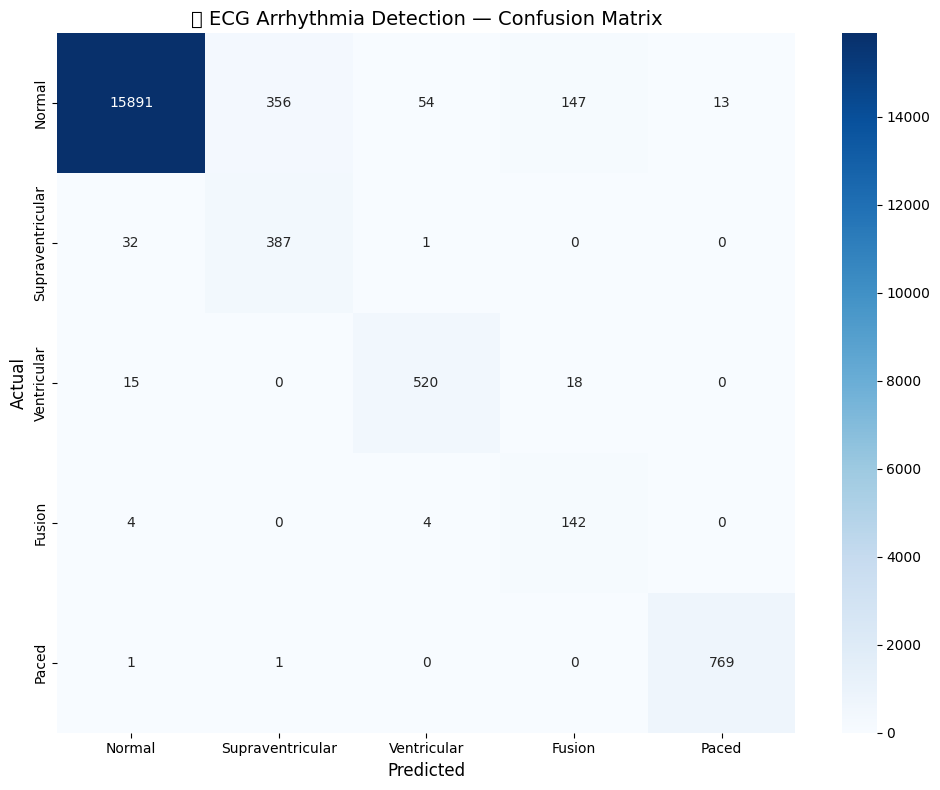


🎯 Test Accuracy: 96.48%


In [37]:
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=used_names, yticklabels=used_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('🫀 ECG Arrhythmia Detection — Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150)
plt.show()
accuracy = np.sum(y_pred == y_test) / len(y_test)
print(f"\n🎯 Test Accuracy: {accuracy:.2%}")

In [38]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

C:\Users\mayank goyal\AppData\Local\Temp\ipykernel_28012\4271127204.py:54: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mayank goyal\AppData\Local\Temp\ipykernel_28012\4271127204.py:55: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  plt.savefig('../models/saliency_visualization.png', dpi=150, bbox_inches='tight')


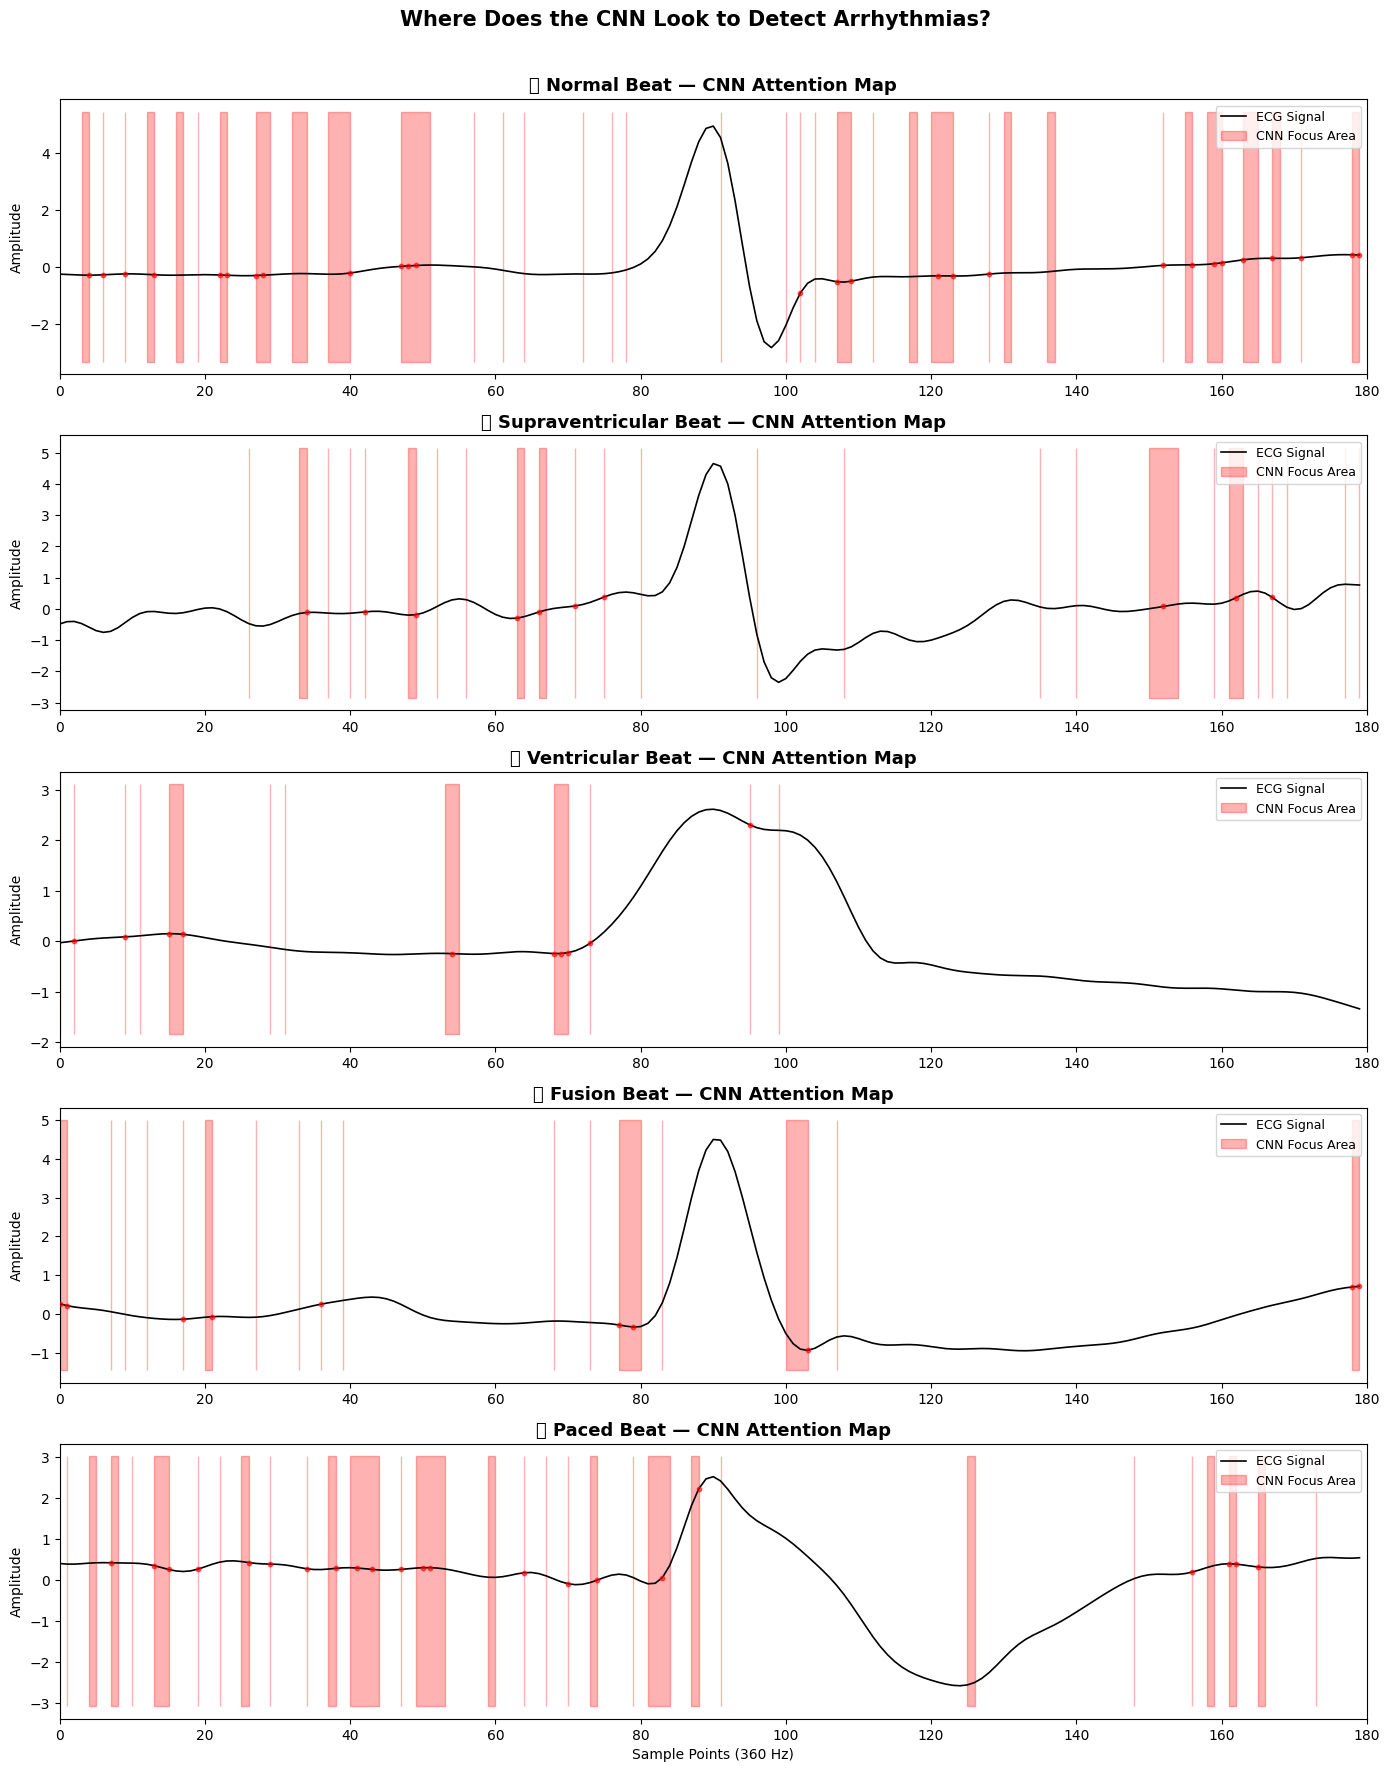

✅ Saliency Map visualization complete!


In [42]:
def saliency_map(model, input_signal, class_idx):
    """Compute gradient of output w.r.t. input — no sub-model needed!"""
    input_tensor = tf.Variable(input_signal, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor, training=False)
        target = predictions[:, class_idx]
    
    grads = tape.gradient(target, input_tensor)
    # Absolute gradients = importance
    saliency = tf.abs(grads).numpy().flatten()
    # Normalize
    saliency = saliency / (saliency.max() + 1e-8)
    return saliency
# Plot for each class
class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Paced']
unique_classes = np.unique(y_test)
fig, axes = plt.subplots(len(unique_classes), 1, figsize=(14, 3.5 * len(unique_classes)))
for idx, cls in enumerate(unique_classes):
    mask = (y_test == cls) & (y_pred == cls)
    if np.sum(mask) == 0:
        axes[idx].set_title(f'{class_names[cls]} — No correct predictions')
        continue
    
    sample_idx = np.where(mask)[0][0]
    sample = X_test[sample_idx:sample_idx+1]
    signal = sample.flatten()
    
    # Compute saliency
    importance = saliency_map(model, sample, cls)
    
    ax = axes[idx]
    
    # Plot ECG signal
    time = np.arange(len(signal))
    ax.plot(time, signal, color='black', linewidth=1.2, label='ECG Signal')
    
    # Overlay importance as red shading
    ax.fill_between(time, signal.min() - 0.5, signal.max() + 0.5,
                     where=importance > 0.3,
                     alpha=0.3, color='red', label='CNN Focus Area')
    
    # Scatter high-importance points
    high_imp = importance > 0.5
    ax.scatter(time[high_imp], signal[high_imp], c='red', s=10, zorder=5, alpha=0.6)
    
    ax.set_title(f'🫀 {class_names[cls]} Beat — CNN Attention Map', fontsize=13, fontweight='bold')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(0, len(signal))
axes[-1].set_xlabel('Sample Points (360 Hz)')
plt.suptitle('Where Does the CNN Look to Detect Arrhythmias?', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../models/saliency_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saliency Map visualization complete!")